# Heart Disease Prediction — Logistic Regression
**Dataset:** `heart.csv` | **Target:** `target` (1 = disease, 0 = no disease)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, recall_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

## 2. Load & Clean Data

In [2]:
df = pd.read_csv("heart.csv")
print(f"Original shape : {df.shape}")
print(f"Null values    : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")

# FIX: Drop duplicates before splitting to prevent data leakage
df = df.drop_duplicates()
print(f"\nCleaned shape  : {df.shape}")
df.head()

Original shape : (1025, 14)
Null values    : 0
Duplicate rows : 723

Cleaned shape  : (302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Exploratory Data Analysis

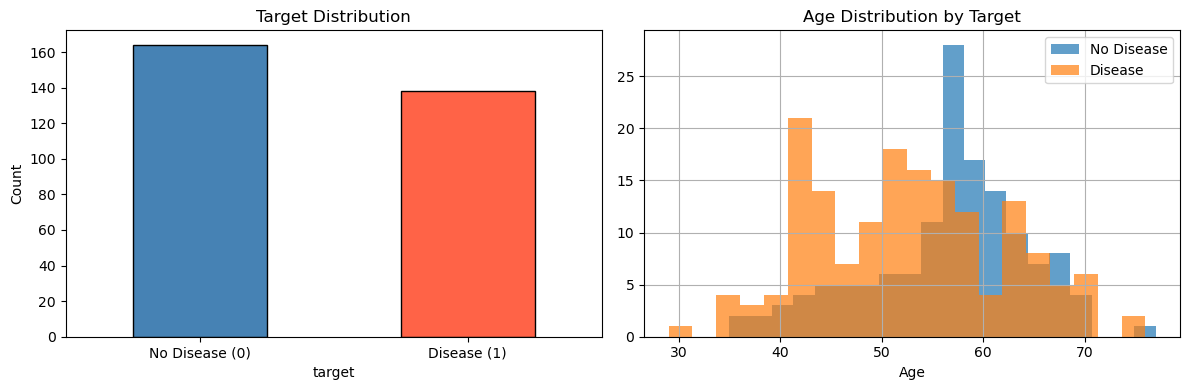

In [3]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["target"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Target Distribution")
axes[0].set_xticklabels(["No Disease (0)", "Disease (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Age distribution by target
df.groupby("target")["age"].hist(ax=axes[1], bins=20, alpha=0.7, label=["No Disease", "Disease"])
axes[1].set_title("Age Distribution by Target")
axes[1].set_xlabel("Age")
axes[1].legend(["No Disease", "Disease"])

plt.tight_layout()
plt.show()

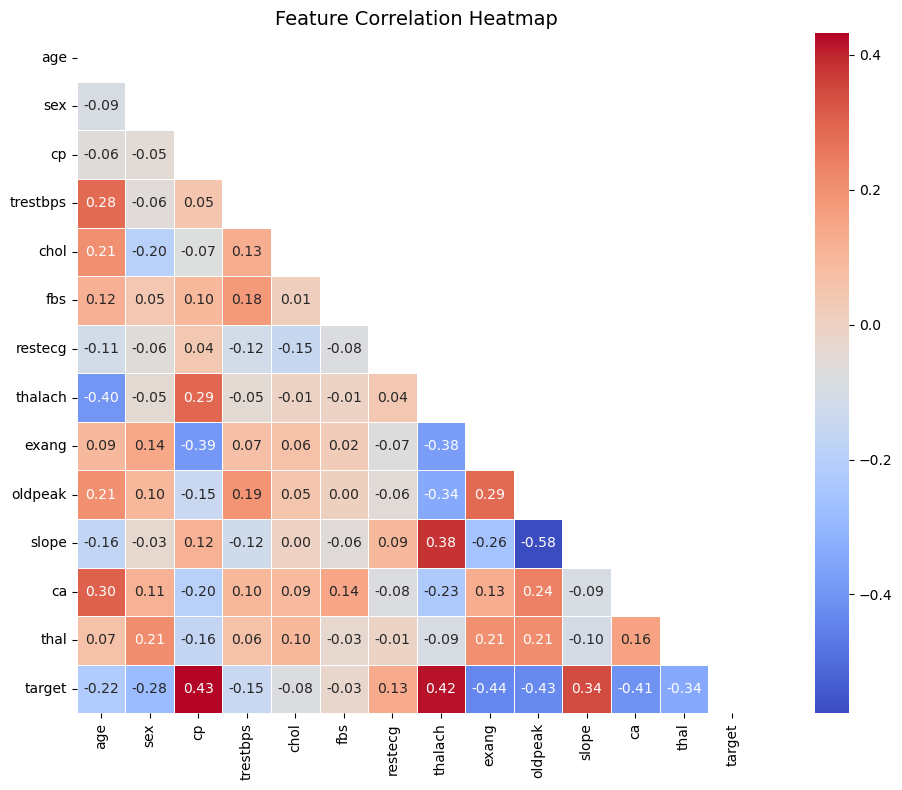

In [4]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Feature & Target Split

In [5]:
X = df.drop("target", axis=1)
y = df["target"]
print(f"Features : {X.shape[1]}")
print(f"Samples  : {len(y)}")
print(f"Class 0  : {(y == 0).sum()} | Class 1 : {(y == 1).sum()}")

Features : 13
Samples  : 302
Class 0  : 138 | Class 1 : 164


## 5. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves class ratio
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train class dist → 0: {(y_train == 0).sum()}, 1: {(y_train == 1).sum()}")

Train: 241 samples | Test: 61 samples
Train class dist → 0: 110, 1: 131


## 6. Feature Scaling

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test (no leakage)

## 7. Train Model

In [8]:
# max_iter=1000 ensures convergence
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 8. Evaluate on Test Set

In [9]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
recall   = recall_score(y_test, y_pred)

print(f"Accuracy Score : {accuracy * 100:.2f}%")
print(f"Recall Score   : {recall:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

Accuracy Score : 80.33%
Recall Score   : 0.8485

              precision    recall  f1-score   support

  No Disease       0.81      0.75      0.78        28
     Disease       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



## 9. 5-Fold Cross-Validation

In [10]:
# Pipeline prevents data leakage across folds
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
print(f"CV Accuracy per fold : {cv_scores.round(4)}")
print(f"Mean ± Std           : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV Accuracy per fold : [0.8361 0.7869 0.9333 0.7667 0.7833]
Mean ± Std           : 0.8213 ± 0.0606


## 10. Confusion Matrix

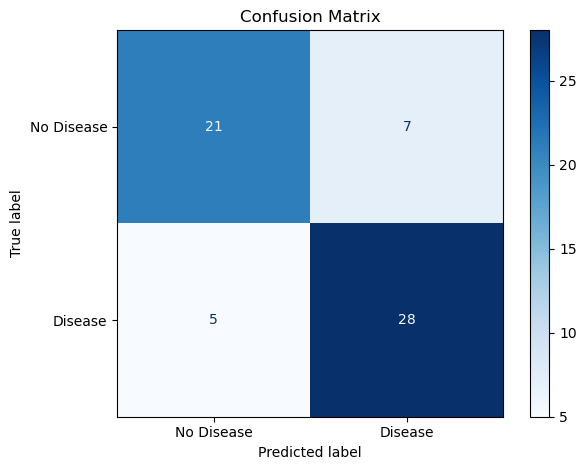

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 11. ROC-AUC Curve

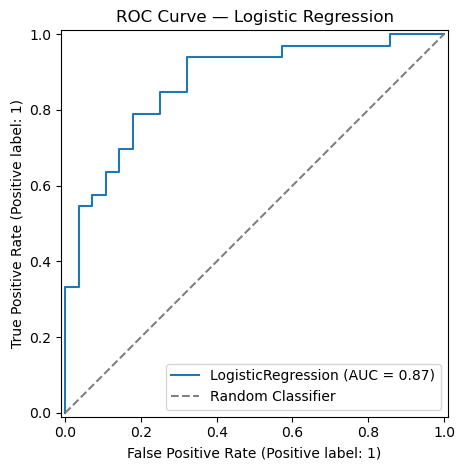

In [12]:
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("ROC Curve — Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Feature Importance (Model Coefficients)

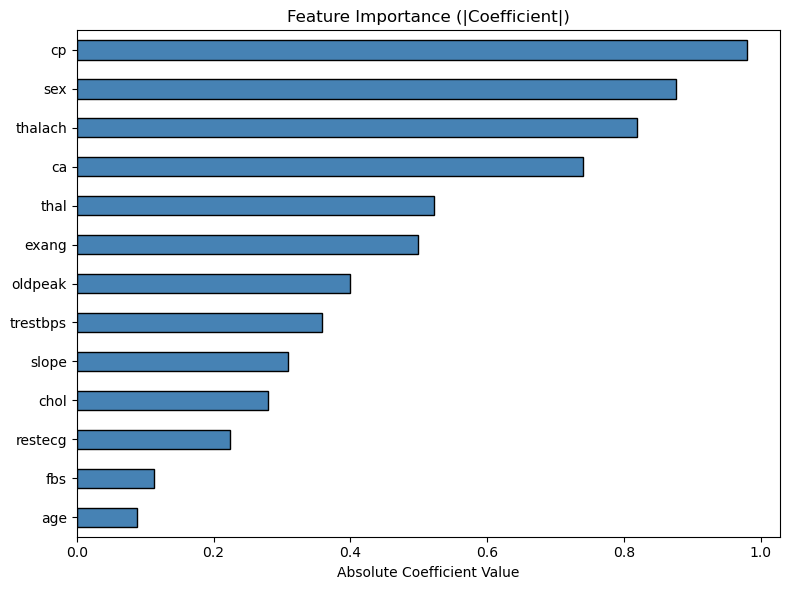

cp          0.978893
sex         0.876002
thalach     0.818189
ca          0.740095
thal        0.521572
exang       0.499109
oldpeak     0.400050
trestbps    0.358746
slope       0.309090
chol        0.279967
restecg     0.224004
fbs         0.112431
age         0.087868


In [13]:
importances = pd.Series(np.abs(model.coef_[0]), index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Feature Importance (|Coefficient|)")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).to_string())